In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/apps.csv')
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [5]:
df.shape

(9659, 14)

In [6]:
df.columns

Index(['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size',
       'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
App,0
Category,0
Rating,1463
Reviews,0
Size,1227
Installs,0
Type,0
Price,0
Content Rating,0


In [8]:
df = df.drop_duplicates()

In [9]:
df = df.dropna(subset=['Rating'])

In [10]:
df['Installs'] = df['Installs'].str.replace('+','', regex=False)
df['Installs'] = df['Installs'].str.replace(',','', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [11]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8196 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      8196 non-null   int64  
 1   App             8196 non-null   object 
 2   Category        8196 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         8196 non-null   int64  
 5   Size            7027 non-null   float64
 6   Installs        8196 non-null   int64  
 7   Type            8196 non-null   object 
 8   Price           8196 non-null   object 
 9   Content Rating  8196 non-null   object 
 10  Genres          8196 non-null   object 
 11  Last Updated    8196 non-null   object 
 12  Current Ver     8192 non-null   object 
 13  Android Ver     8194 non-null   object 
dtypes: float64(2), int64(3), object(9)
memory usage: 960.5+ KB


In [13]:
df['Category'].value_counts().head(10)

,count
Category,
FAMILY,1608
GAME,912
TOOLS,718
FINANCE,302
PRODUCTIVITY,301
LIFESTYLE,301
PERSONALIZATION,298
MEDICAL,290
BUSINESS,263


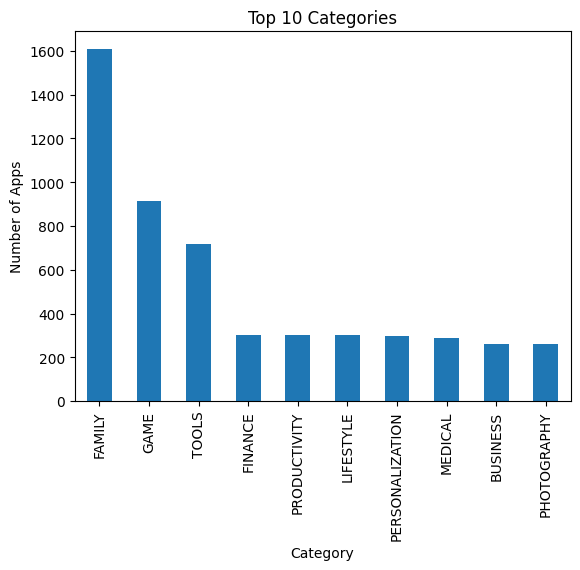

In [14]:
df['Category'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Categories')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.show()

In [15]:
print("Average Rating:", df['Rating'].mean())

Average Rating: 4.173243045387993


In [16]:
df[['App','Rating']].sort_values(
    by='Rating',
    ascending=False
).head(10)

,App,Rating
9594,Monster Ride Pro,5.0
9638,Fr. Daoud Lamei,5.0
9655,Fr. Mike Schmitz Audio Teachings,5.0
6464,CL Keyboard - Myanmar Keyboard (No Ads),5.0
6456,CL REPL,5.0
6433,Tic Tac CK,5.0
6429,CK Employee Portal,5.0
6428,USMLE Step 2 CK Flashcards,5.0
6417,211:CK,5.0
6746,CR Tracker for Chests,5.0


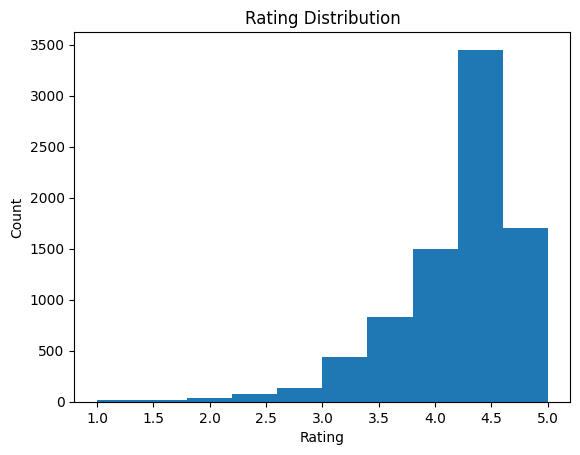

In [17]:
plt.hist(df['Rating'])

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [18]:
popular = df.groupby('Category')['Installs'].sum()

popular.sort_values(
    ascending=False
).head(10)

,Installs
Category,
GAME,13878762717
COMMUNICATION,11038241530
TOOLS,7999724500
PRODUCTIVITY,5793070180
SOCIAL,5487841475
PHOTOGRAPHY,4649143130
FAMILY,4427479590
VIDEO_PLAYERS,3926797200
TRAVEL_AND_LOCAL,2894859300


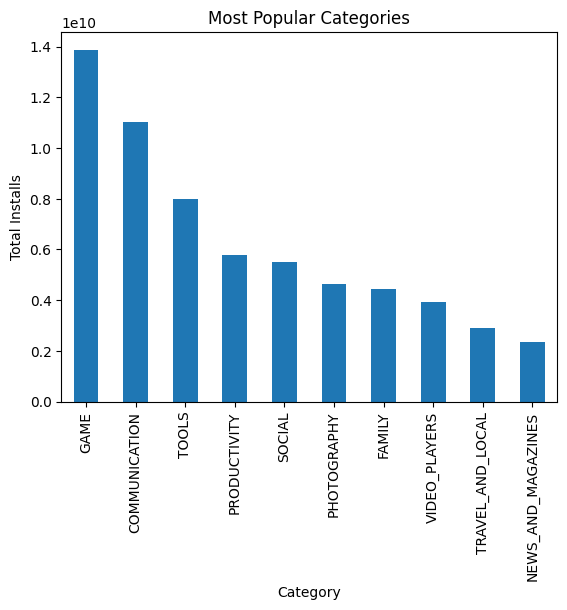

In [19]:
popular.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title('Most Popular Categories')
plt.xlabel('Category')
plt.ylabel('Total Installs')
plt.show()

In [20]:
df['Type'].value_counts()

,count
Type,
Free,7592
Paid,604


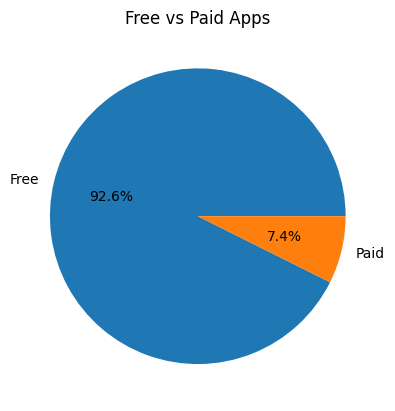

In [21]:
df['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Free vs Paid Apps')
plt.ylabel('')
plt.show()

In [22]:
df['Content Rating'].value_counts()

,count
Content Rating,
Everyone,6618
Teen,912
Mature 17+,357
Everyone 10+,305
Adults only 18+,3
Unrated,1


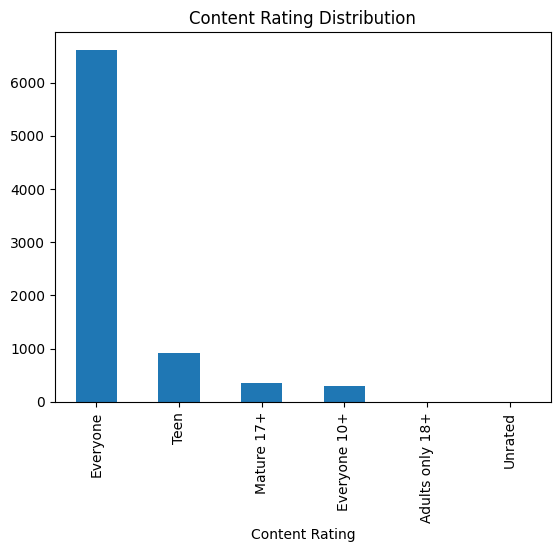

In [23]:
df['Content Rating'].value_counts().plot(kind='bar')

plt.title('Content Rating Distribution')
plt.show()